In [1]:
import rebayes_mini

In [2]:
import jax
jax.config.update("jax_enable_x64", True)
import chex
import numpy as np
import pandas as pd
import seaborn as sns
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial
from rebayes_mini import callbacks

cmap = {
    "EKF-IW": "crimson",
    "EKF": "lightseagreen",
    "WoLF-IMQ": "dodgerblue",
    "WoLF-MD": "gold",
    "EKF-B": "darkorange",
    "EKF-PrO": "mediumorchid",
    "UKF": "teal",
    "CKF": "indigo",
    "UKF-PrO": "deeppink",
    "CKF-PrO": "olive",
}

def euler_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    return y + k1

def rk4_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    k2 = h * f(y + k1 / 2, dt * i + h / 2, i)
    k3 = h * f(y + k2 / 2, t + h / 2, i)
    k4 = h * f(y + k3, t + h, i)

    y_next = y + 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return y_next

@partial(jax.jit, static_argnames=("f",))
def solve(ys, dt, N, f):
    @jax.jit
    def step(i, ys):
        ysi = euler_step(ys[i - 1], i, dt, f)
        return ys.at[i].set(ysi)
    return jax.lax.fori_loop(1, N, step, ys)

In [3]:
errs = {}
mses = {}
nlls = {}

In [4]:
D = 60
N = 10000
dt = 0.002
sigma = 1.0
F = 8.0
n_hidden = 2

@partial(jax.vmap, in_axes=(None, 0, None))
def fcoord(x, k, D):
    xdot = (x[(k + 1) % D] - x[k - 2]) * x[k - 1] - x[k] + F
    return xdot

key = jax.random.PRNGKey(1) #original is 315
key_init, key_sim, key_eval = jax.random.split(key, 3)
key_state, key_measurement = jax.random.split(key_sim)

transition_prob = 0.995
key_hidden, key_state = jax.random.split(key_state)
transition_state = jnp.ones((n_hidden, n_hidden)) * 1/(n_hidden-1) * (1-transition_prob)
transition_state = transition_state.at[jnp.diag_indices_from(transition_state)].set(transition_prob)

key_hidden, key_state = jax.random.split(key_state)
phi_hidden = jax.random.normal(key_hidden, (D, n_hidden-1)) * sigma
phi_hidden = jnp.concatenate([jnp.zeros((D, 1)), phi_hidden], -1)
observation_covariance = 5.0

@jax.jit
def f(x, t, i, regime):
    keyt = jax.random.fold_in(key_state, i)
    key_regime, keyt = jax.random.split(keyt)
    probabilities = transition_state[regime, :]
    logits = jnp.log(probabilities)
    regime_next = jax.random.categorical(key_regime, logits)

    ixs = jnp.arange(D)
    xdot = fcoord(x, ixs, D) + phi_hidden[:, regime_next]
    return xdot, regime_next

x0 = jax.random.normal(key_init, (D,))
x_init = jnp.copy(x0)
xs = jnp.zeros((N,) + x0.shape)
xs = xs.at[0].set(x0)
fpart = partial(f, D=D)
regime = int(0)
regs = [0]
for i in range(1, N):
    xdot, regime = f(x0, i * dt, i, regime)
    x0 = x0 + dt * xdot
    regs.append(regime)
    xs = xs.at[i].set(x0)


ys = xs + jnp.sqrt(observation_covariance) * jax.random.normal(key_measurement, xs.shape)
range_time = np.arange(N) * dt

def latent_fn(x):
    """
    State function
    """
    @jax.jit
    def f(x, t, _):
        ixs = jnp.arange(D)
        return fcoord(x, ixs, D)
    
    return euler_step(x, 0, dt, f)


def obs_fn(x, _):#, key, i):
    """
    Measurement function
    """
    #err = jax.random.normal(key, (D,))
    return x

# EKF

In [5]:
#from rebayes_mini.methods import robust_filter as rkf
from profilter import ExtendedKalmanFilter
method = "EKF"

nsteps = xs.shape[0]
agent_imq = ExtendedKalmanFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
    )

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

init_bel = agent_imq.init_bel(x_init, cov=1.0)
filterfn = partial(agent_imq.scan, callback_fn=get_mean_and_cov)
_, (hist, hist_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist - xs), -1))
errs[method] = err

mse = jnp.mean(jnp.square(hist-xs))
mses[method] = mse

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

nll_per_step = jax.vmap(nll_step)(xs, hist, hist_cov)
nlls[method] = nll_per_step
jnp.mean(nll_per_step)

Array(861.73390867, dtype=float64)

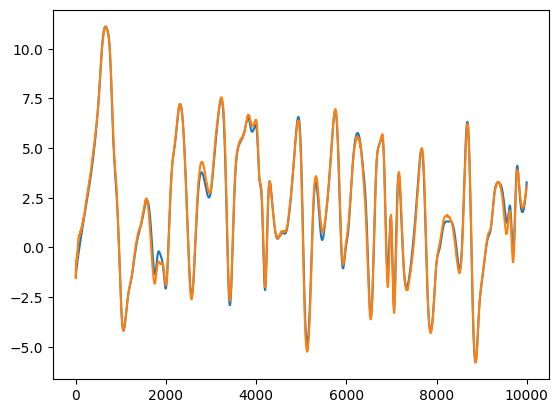

In [6]:
plt.plot(xs[:, 12])
plt.plot(hist[:, 12])

# EKF-PrO

In [7]:
from profilter_rebuttal import PrOFilter
method = "EKF-PrO"

nsteps = xs.shape[0]
agent_imq = PrOFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        n_inner=5,
        n_outer=10,
    )

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

init_bel = agent_imq.init_bel(x_init, cov=1.0)
filterfn = partial(agent_imq.scan, callback_fn=get_mean_and_cov)
_, (hist1, hist1_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist1 - xs), -1))
errs[method] = err

mse = jnp.mean(jnp.square(hist1-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist1, hist1_cov)
nlls[method] = nll_per_step
jnp.mean(nll_per_step)

Array(524.47681384, dtype=float64)

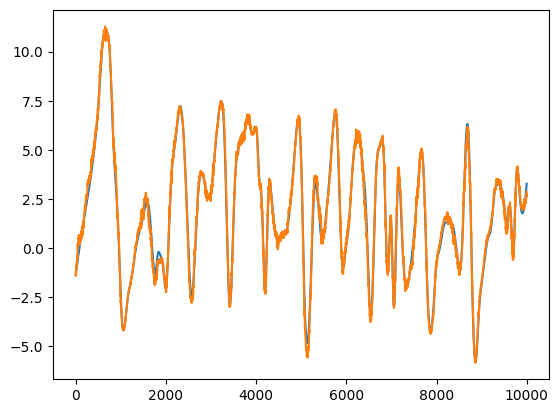

In [8]:
plt.plot(xs[:, 12])
plt.plot(hist1[:, 12])

# UKF

In [9]:
from unscented import UnscentedKalmanFilter
method = "UKF"

nsteps = xs.shape[0]
agent_ukf = UnscentedKalmanFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
    )

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

init_bel = agent_ukf.init_bel(x_init, cov=1.0)
filterfn = partial(agent_ukf.scan, callback_fn=get_mean_and_cov)
_, (hist2, hist2_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist2 - xs), -1))
errs[method] = err

mse = jnp.mean(jnp.square(hist2-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist2, hist2_cov)
nlls[method] = nll_per_step
jnp.mean(nll_per_step)

Array(846.55305889, dtype=float64)

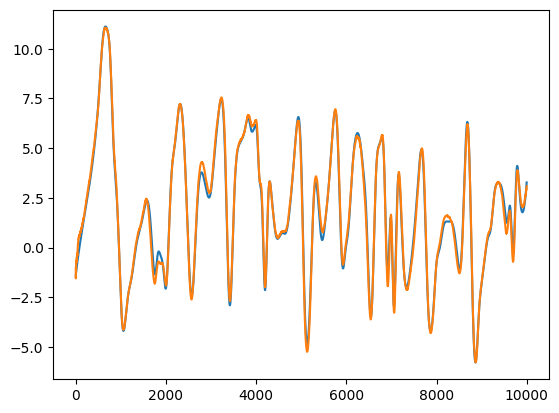

In [10]:
plt.plot(xs[:, 12])
plt.plot(hist2[:, 12])

# UKF_PrO

In [11]:
from unscented import UKFPrOFilterPred
method = "UKF-PrO"

nsteps = xs.shape[0]
agent_ukfpro = UKFPrOFilterPred(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        n_inner=5, #original 3
        n_outer=10,
    )

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

init_bel = agent_ukfpro.init_bel(x_init, cov=1.0)
filterfn = partial(agent_ukfpro.scan, callback_fn=get_mean_and_cov)
_, (hist3, hist3_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist3 - xs), -1))
errs[method] = err

mse = jnp.mean(jnp.square(hist3-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist3, hist3_cov)
nlls[method] = nll_per_step
jnp.mean(nll_per_step)

Array(515.62043121, dtype=float64)

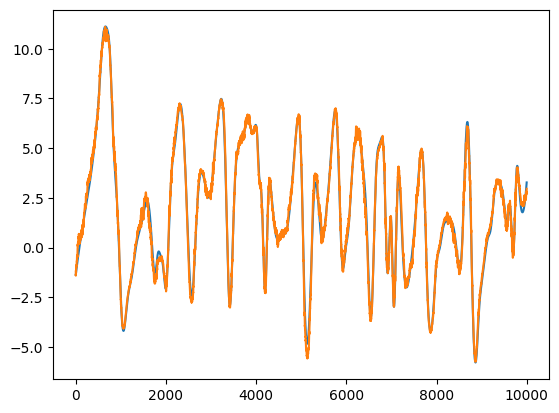

In [12]:
plt.plot(xs[:, 12])
plt.plot(hist3[:, 12])

# CKF

In [13]:
from unscented import CubatureKalmanFilter
method = "CKF"

nsteps = xs.shape[0]
agent_ckf = CubatureKalmanFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
    )

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

init_bel = agent_ckf.init_bel(x_init, cov=1.0)
filterfn = partial(agent_ckf.scan, callback_fn=get_mean_and_cov)
_, (hist4, hist4_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist4 - xs), -1))
errs[method] = err

mse = jnp.mean(jnp.square(hist4-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist4, hist4_cov)
nlls[method] = nll_per_step
jnp.mean(nll_per_step)

Array(842.88354187, dtype=float64)

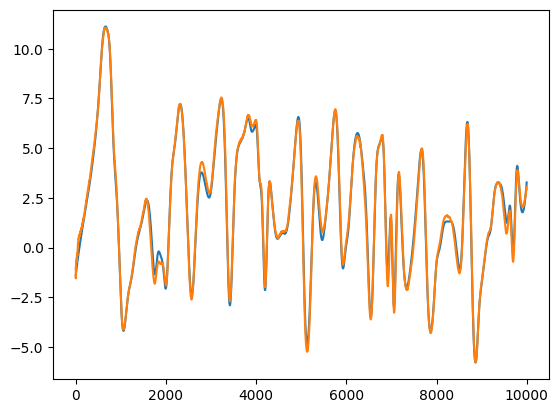

In [14]:
plt.plot(xs[:, 12])
plt.plot(hist4[:, 12])

# CKF-PrO

In [15]:
from unscented import CKFPrOFilterPred
method = "CKF-PrO"

nsteps = xs.shape[0]
agent_ckfpro = CKFPrOFilterPred(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        n_inner=5,
        n_outer=10,
    )

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

init_bel = agent_ckfpro.init_bel(x_init, cov=1.0)
filterfn = partial(agent_ckfpro.scan, callback_fn=get_mean_and_cov)
_, (hist5, hist5_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

err = jnp.sqrt(jnp.sum(jnp.square(hist5 - xs), -1))
errs[method] = err

mse = jnp.mean(jnp.square(hist5-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist5, hist5_cov)
nlls[method] = nll_per_step
jnp.mean(nll_per_step)

Array(445.2990861, dtype=float64)

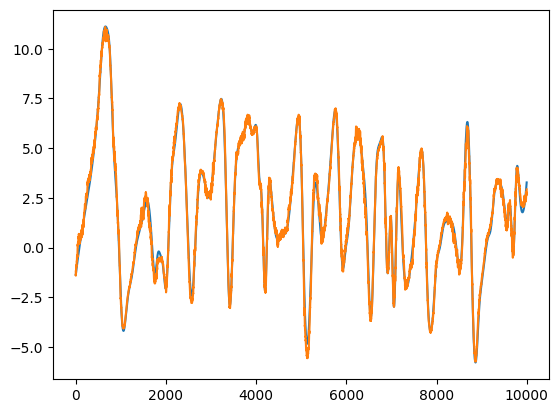

In [16]:
plt.plot(xs[:, 12])
plt.plot(hist5[:, 12])

# Plots

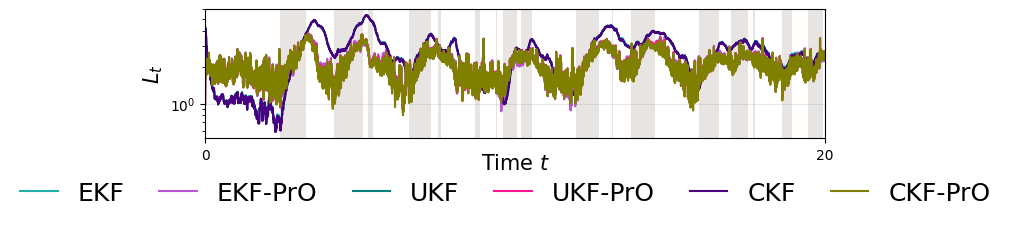

In [17]:
delta = dt
n_steps = err.shape[0]
ts = jnp.arange(n_steps) * delta
colors = {
    0: "white",
    1: "#D8D3CD",
}
label = np.array(regs)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.8))

for i, value in enumerate(np.array(label)):
    ax.axvspan(
        i * delta,
        (i + 1) * delta,
        color=colors[value],
        alpha=0.6,
        linewidth=0,
    )

for m in ["EKF", "EKF-PrO", "UKF", "UKF-PrO", "CKF", "CKF-PrO"]:
    ax.plot(ts, errs[m], label=m, c=cmap[m])

ax.set_xlim(0, len(label) * delta)
ax.set_ylabel(r"$L_t$", fontsize=15)
ax.set_yscale("log")
ax.grid(alpha=0.3)
ax.set_xticks([0, 20])

# Put xlabel close to the axis, but not in the legend area
ax.set_xlabel(r"Time $t$", fontsize=15)
ax.xaxis.set_label_coords(0.5, -0.12)

# Reserve enough bottom margin for both xlabel and legend
fig.subplots_adjust(bottom=0.42)

handles, legend_labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.10),
    ncol=len(legend_labels),
    fontsize=18,
    frameon=False,
    handlelength=1.5,
    columnspacing=1.4,
)

fig.savefig("error_lorenz.pdf", bbox_inches="tight")

# EKF vs EKF-PrO

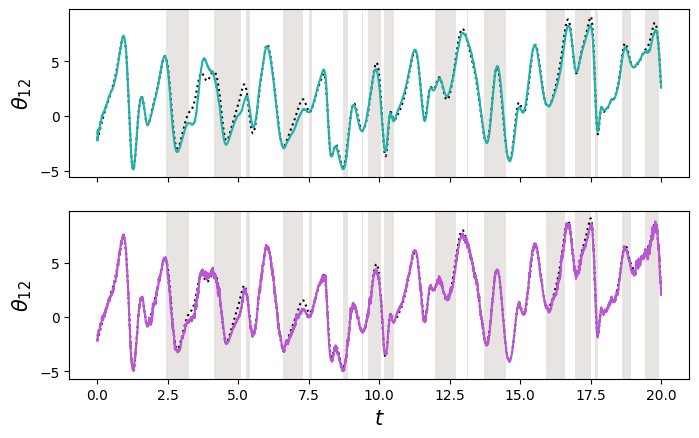

In [18]:
delta = dt
n_steps = err.shape[0]
ts = jnp.arange(n_steps) * delta
colors = {
    0: "white",
    1: "#D8D3CD",
}
label = np.array(regs)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.8), nrows=2, ncols=1, sharex=True)

for i, value in enumerate(np.array(label)):
    for a in ax:
        a.axvspan(
        i * delta,
        (i + 1) * delta,
        color=colors[value],
        alpha=0.6,
        linewidth=0,
        )

idx = jnp.argmax(jnp.mean(jnp.square(hist-xs), 0))


for a in ax:
    a.plot(ts, xs[:, idx], c='k', linestyle='dotted')

ax[0].plot(ts, hist[:, idx], c=cmap['EKF'])
ax[1].plot(ts, hist1[:, idx], c=cmap['EKF-PrO'])

for a in ax:
    a.set_ylabel(r'$\theta_{12}$', fontsize=15)

ax[1].set_xlabel(r'$t$', fontsize=15)
fig.savefig("lorenz_trace.pdf", bbox_inches="tight")

# EKF vs UKF

Text(0.5, 0, '$t$')

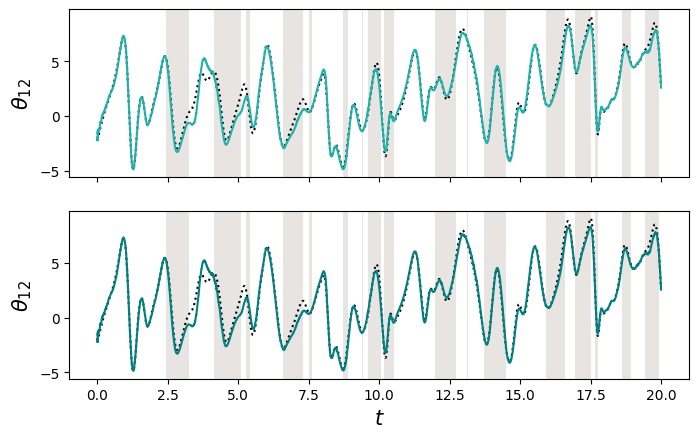

In [19]:
delta = dt
n_steps = err.shape[0]
ts = jnp.arange(n_steps) * delta
colors = {
    0: "white",
    1: "#D8D3CD",
}
label = np.array(regs)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.8), nrows=2, ncols=1, sharex=True)

for i, value in enumerate(np.array(label)):
    for a in ax:
        a.axvspan(
        i * delta,
        (i + 1) * delta,
        color=colors[value],
        alpha=0.6,
        linewidth=0,
        )

idx = jnp.argmax(jnp.mean(jnp.square(hist-xs), 0))


for a in ax:
    a.plot(ts, xs[:, idx], c='k', linestyle='dotted')

ax[0].plot(ts, hist[:, idx], c=cmap['EKF'])
ax[1].plot(ts, hist2[:, idx], c=cmap['UKF'])

for a in ax:
    a.set_ylabel(r'$\theta_{12}$', fontsize=15)

ax[1].set_xlabel(r'$t$', fontsize=15)

In [20]:
for m in ["EKF", "UKF", "CKF", "EKF-PrO", "UKF-PrO", "CKF-PrO"]:
    print(f"{m}: mean error = {jnp.mean(errs[m]):.4f}, MSE = {mses[m]:.4f}, mean NLL = {jnp.mean(nlls[m]):.4f}")

EKF: mean error = 2.5200, MSE = 0.1231, mean NLL = 861.7339
UKF: mean error = 2.5015, MSE = 0.1216, mean NLL = 846.5531
CKF: mean error = 2.4991, MSE = 0.1213, mean NLL = 842.8835
EKF-PrO: mean error = 2.0760, MSE = 0.0766, mean NLL = 524.4768
UKF-PrO: mean error = 2.0639, MSE = 0.0758, mean NLL = 515.6204
CKF-PrO: mean error = 2.0423, MSE = 0.0742, mean NLL = 445.2991


/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_9519/4241452379.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=mse_df, palette=cmap, order=methods)
/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_9519/4241452379.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=nll_df, palette=cmap, order=methods)


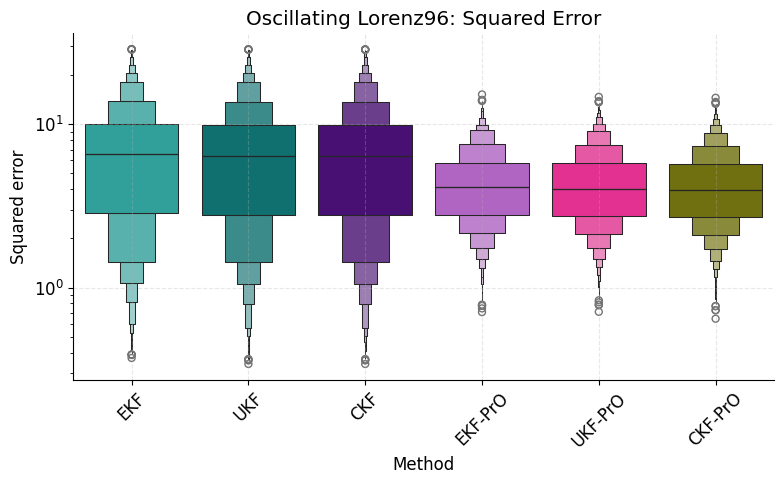

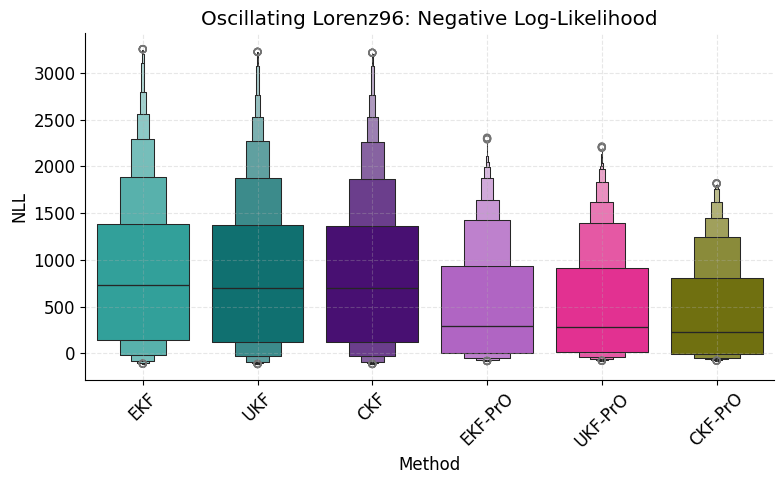

In [24]:
import pandas as pd
import seaborn as sns

methods = ["EKF", "UKF", "CKF", "EKF-PrO", "UKF-PrO", "CKF-PrO"]

# --- Build long-format DataFrames, one row per (time step, method) ---
mse_rows = []
nll_rows = []
for m in methods:
    for t, (e, n) in enumerate(zip(errs[m]**2, nlls[m])):
        mse_rows.append({"method": m, "step": t, "error": float(e)})
        nll_rows.append({"method": m, "step": t, "error": float(n)})

mse_df = pd.DataFrame(mse_rows)
nll_df = pd.DataFrame(nll_rows)

# --- MSE boxenplot ---
plt.figure(figsize=(8, 5))
sns.boxenplot(y="error", x="method", data=mse_df, palette=cmap, order=methods)
plt.xlabel("Method")
plt.ylabel("Squared error")
plt.grid(alpha=0.3)
plt.yscale("log")
plt.title("Oscillating Lorenz96: Squared Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lorenz_oscillating_mse.pdf")

mse_df.to_csv("lorenz_oscillating_mse.csv", index=False)

# --- NLL boxenplot ---
plt.figure(figsize=(8, 5))
sns.boxenplot(y="error", x="method", data=nll_df, palette=cmap, order=methods)
plt.xlabel("Method")
plt.ylabel("NLL")
plt.grid(alpha=0.3)
plt.title("Oscillating Lorenz96: Negative Log-Likelihood")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lorenz_oscillating_nll.pdf")

nll_df.to_csv("lorenz_oscillating_nll.csv", index=False)

In [26]:
for i, cell in enumerate(nb['cells']):
    src = ''.join(cell['source'])
    if 'import' in src and ('euler' in src.lower()):
        print(f"Cell {i}: {src}")

NameError: name 'nb' is not defined